# Energy spectra

Compute the energy spectra for real data as either a Fourier transform in the zonal direction, or a spherical harmonic transform for global data in two dimensions.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from scores.dynamics import power_spectra
import matplotlib.pyplot as plt

In [2]:
START_TIME = pd.Timestamp("2020-01-01")
END_TIME = pd.Timestamp("2020-02-01")
ds = xr.open_zarr("gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr")
ds = ds.sel(time=slice(START_TIME, END_TIME))

Prepare the data, selecting the desired fields (velocity components for kinetic energy, and any others of interest), and ordering dimensions as required.

In [3]:
fieldnames = ['u_component_of_wind','v_component_of_wind','temperature','geopotential']
ds = ds[fieldnames]
ds = ds.compute()
ds = ds.rename({'u_component_of_wind': 'u', 'v_component_of_wind': 'v', 'temperature': 't', 'geopotential': 'z'})
ds = ds.transpose('time', 'level', 'latitude', 'longitude')

Compute the zonal Fourier transform of the kinetic energy, $K = (u^2 + v^2)/2$ as the default, averaging over the vertical and temporal dimensions

In [4]:
Khat = power_spectra(ds, reduce_vertical=True, reduce_time=True)

Plot the power spectra for the zonal kinetic energy as a function of spatial frequency at the equator, averaged over the vertical and temporal dimensions, and compare this to the $k^{-3}$ theoretical rate of energy transfer for two dimensional turbulence.

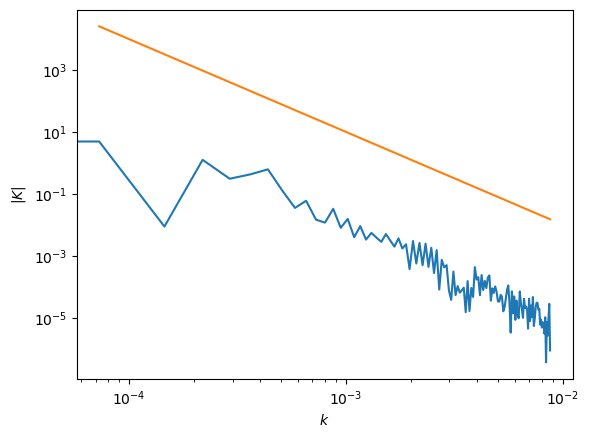

In [5]:
freq = Khat['frequency'].to_numpy()
amp_sq = Khat['amplitude_squared'].to_numpy()
lat=amp_sq.shape[0]//2
plt.loglog(freq[lat,:],amp_sq[lat,:])
plt.plot(freq[lat,1:],1.0e-8*np.power(freq[lat,1:],-3.))
plt.ylabel(r'$|K|$')
plt.xlabel(r'$k$')
plt.show()

This time, preserve the vertical and temporal dimensions

In [6]:
Khat = power_spectra(ds, reduce_vertical=False, reduce_time=False)

...and average over the equatorial latitudes and plot the spectra for the first time at 850 hPa.

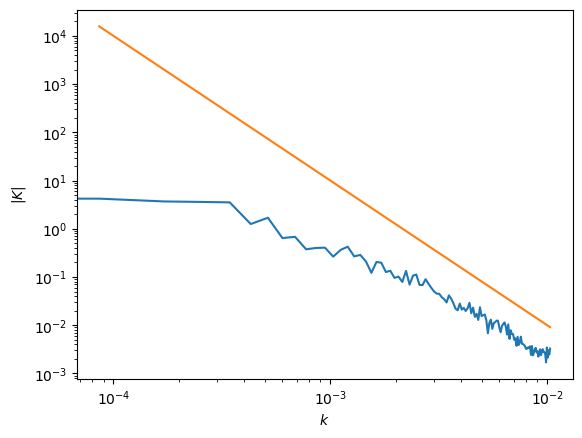

In [7]:
lats = Khat.latitude[(Khat.latitude >= -15.0) & (Khat.latitude <= +15.0)]
Khat_eq = Khat.sel(latitude=lats,time=Khat.time.values[0],level=Khat.level.values[-3])
Khat_eq_avg = Khat_eq.mean(dim='latitude')
freq = Khat_eq_avg['frequency'].to_numpy()
amp_sq = Khat_eq_avg['amplitude_squared'].to_numpy()
plt.loglog(freq,amp_sq)
plt.plot(freq[1:],1.0e-8*np.power(freq[1:],-3.))
plt.ylabel(r'$|K|$')
plt.xlabel(r'$k$')
plt.show()

We can also compute the spectra for a subdomain in both latitude and longitude (for which a cosine bell filter is applied in the zonal direction).

In [8]:
lons = ds.longitude[(ds.longitude < +180.0)]
lats = ds.latitude[(ds.latitude >= -15.0) & (ds.latitude <= +15.0)]
ds_subdomain = ds.sel(latitude=lats, longitude=lons)
Khat = power_spectra(ds_subdomain, reduce_vertical=False, reduce_time=False)

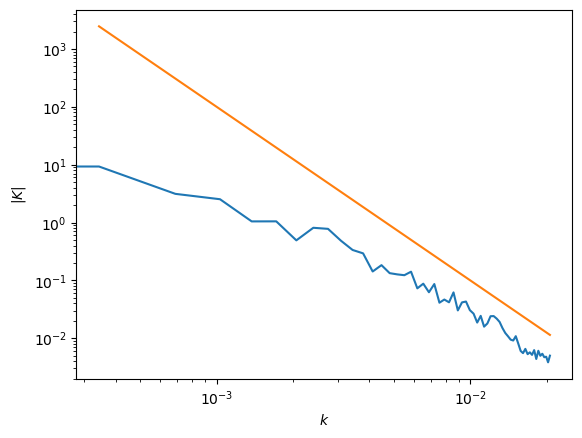

In [9]:
Khat_eq_avg = Khat.sel(time=Khat.time.values[0],level=Khat.level.values[-3]).mean(dim='latitude')
freq = Khat_eq_avg['frequency'].to_numpy()
amp_sq = Khat_eq_avg['amplitude_squared'].to_numpy()
plt.loglog(freq,amp_sq)
plt.plot(freq[1:],1.0e-7*np.power(freq[1:],-3.))
plt.ylabel(r'$|K|$')
plt.xlabel(r'$k$')
plt.show()

Instead of the kinetic energy, we can also compute the spectra for a custom field, in this case the temperature

In [10]:
That = power_spectra(ds, reduce_vertical=False, reduce_time=False, custom_field_name='t')

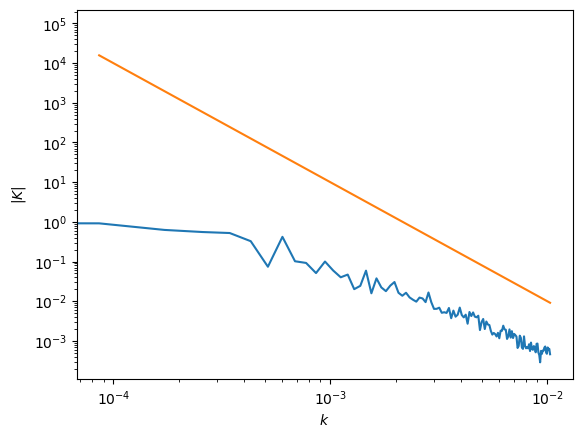

In [11]:
That_eq_avg = That.sel(latitude=lats,time=That.time.values[0],level=That.level.values[-3]).mean(dim='latitude')
freq = That_eq_avg['frequency'].to_numpy()
amp_sq = That_eq_avg['amplitude_squared'].to_numpy()
plt.loglog(freq,amp_sq)
plt.plot(freq[1:],1.0e-8*np.power(freq[1:],-3.))
plt.ylabel(r'$|K|$')
plt.xlabel(r'$k$')
plt.show()